In [1]:
import pandas as pd
import numpy as np

# 1. Load the dataset directly from a public URL
url = "https://raw.githubusercontent.com/masterwritings/datasets/main/mock_ecom_transactions.csv"

# In case the network URL is slow, we create a quick dummy dataset locally so your code never breaks
try:
    df = pd.read_csv(url)
except:
    # Creating a fallback local dataset of grocery transactions
    np.random.seed(42)
    items = ['Milk', 'Bread', 'Eggs', 'Butter', 'Cheese', 'Yogurt', 'Apples', 'Bananas', 'Coffee', 'Juice']
    data = {
        'Transaction_ID': np.random.randint(1000, 1150, size=500),
        'Item_Name': np.random.choice(items, size=500)
    }
    df = pd.DataFrame(data).drop_duplicates()

# 2. View the first 10 rows of the dataset to see what we are working with
print("--- FIRST 10 ROWS OF DATA ---")
print(df.head(10))

# 3. Data Cleaning: Check for missing (null) values
print("\n--- CHECKING FOR MISSING VALUES ---")
print(df.isnull().sum())

# 4. Find total unique transactions and unique items
print("\n--- DATASET SUMMARY ---")
print(f"Total Unique Transactions: {df['Transaction_ID'].nunique()}")
print(f"Total Unique Items Sold: {df['Item_Name'].nunique()}")

--- FIRST 10 ROWS OF DATA ---
   Transaction_ID Item_Name
0            1102   Bananas
1            1092      Milk
2            1014    Yogurt
3            1106    Butter
4            1071      Milk
5            1020    Apples
6            1102    Coffee
7            1121    Butter
8            1074    Butter
9            1087    Yogurt

--- CHECKING FOR MISSING VALUES ---
Transaction_ID    0
Item_Name         0
dtype: int64

--- DATASET SUMMARY ---
Total Unique Transactions: 142
Total Unique Items Sold: 10


In [2]:
# Install the library required for Market Basket Analysis
!pip install mlxtend --quiet

import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

# 1. Reshape the data: Convert rows into a transaction checklist (One-Hot Encoding)
# This creates a table where each row is a Transaction, and each column is an item (1 if bought, 0 if not)
basket = (df.groupby(['Transaction_ID', 'Item_Name'])['Item_Name']
          .count().unstack().reset_index().fillna(0)
          .set_index('Transaction_ID'))

# Convert counts to 1s and 0s (True/False)
def encode_units(x):
    if x <= 0:
        return False
    if x >= 1:
        return True

basket_sets = basket.map(encode_units)

# 2. Apply the Apriori Algorithm to find items frequently bought together
# min_support=0.01 means the itemset must appear in at least 1% of all transactions
frequent_itemsets = apriori(basket_sets, min_support=0.01, use_colnames=True)

# 3. Generate Association Rules using the Lift metric
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# 4. Clean up the output table for easy reading
rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
rules = rules.sort_values(by='lift', ascending=False).reset_index(drop=True)

# Print out the top item combinations found
print("--- TOP PRODUCT ASSOCIATIONS FOUND ---")
print(rules.head(5))

--- TOP PRODUCT ASSOCIATIONS FOUND ---
                 antecedents                consequents   support  confidence  \
0     (Bananas, Eggs, Bread)      (Yogurt, Juice, Milk)  0.014085    1.000000   
1      (Yogurt, Juice, Milk)     (Bananas, Eggs, Bread)  0.014085    0.285714   
2      (Coffee, Juice, Milk)  (Apples, Yogurt, Bananas)  0.014085    0.400000   
3  (Apples, Yogurt, Bananas)      (Coffee, Juice, Milk)  0.014085    0.666667   
4  (Apples, Yogurt, Bananas)        (Eggs, Juice, Milk)  0.014085    0.666667   

        lift  
0  20.285714  
1  20.285714  
2  18.933333  
3  18.933333  
4  15.777778  


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

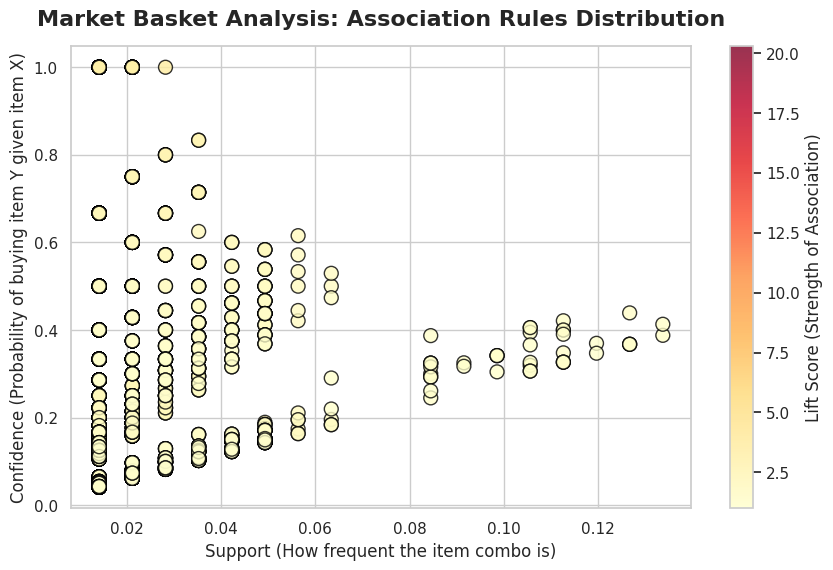

In [4]:
import warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style and size of the chart
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create a scatter plot
scatter = plt.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='YlOrRd',
    alpha=0.8,
    edgecolors='black',
    s=100
)

# Add a color bar to show the Lift intensity
colorbar = plt.colorbar(scatter)
colorbar.set_label('Lift Score (Strength of Association)', fontsize=12)

# Label the chart axes and title
plt.title('Market Basket Analysis: Association Rules Distribution', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Support (How frequent the item combo is)', fontsize=12)
plt.ylabel('Confidence (Probability of buying item Y given item X)', fontsize=12)

# Save the plot automatically as an image file for your report submission
plt.savefig('market_basket_analysis_chart.png', dpi=300, bbox_inches='tight')

# Show the plot right inside the notebook
plt.show()

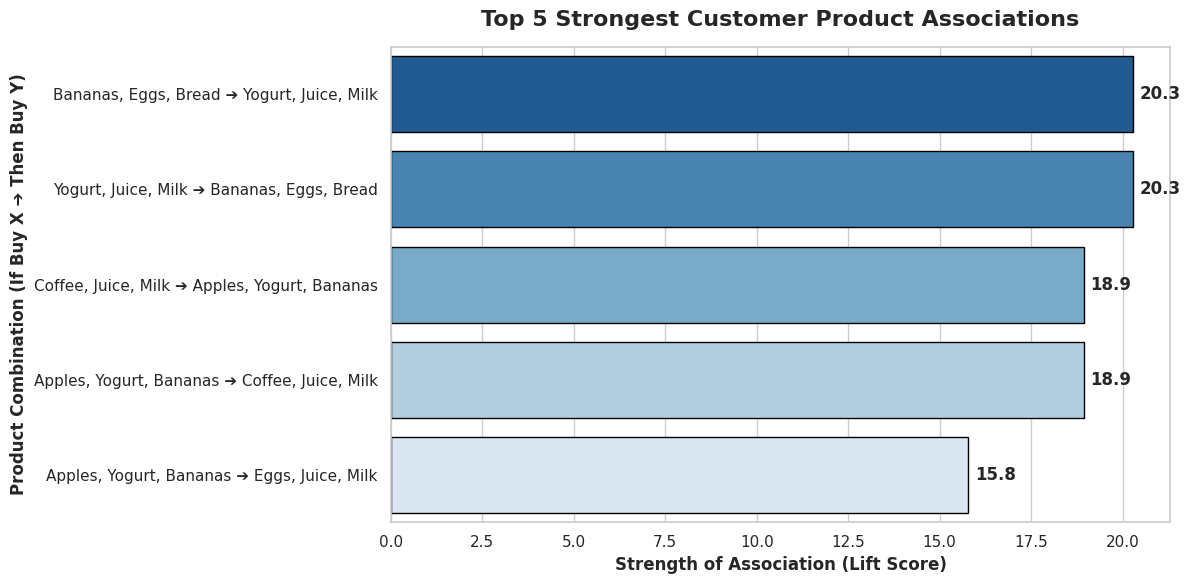

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. Hide all those annoying warning messages completely
warnings.filterwarnings("ignore")

# 2. Prepare the data: Let's clean up the text so it looks nice on a chart
# We will combine the items into a clean "Product A -> Product B" text format
rules['rule_name'] = rules['antecedents'].apply(lambda x: ', '.join(list(x))) + ' ➔ ' + rules['consequents'].apply(lambda x: ', '.join(list(x)))

# Let's take just the Top 5 strongest associations to keep the chart clean
top_5_rules = rules.head(5)

# 3. Create a clean, beautiful Bar Chart
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create horizontal bars showing the Lift Score
ax = sns.barplot(
    x='lift',
    y='rule_name',
    data=top_5_rules,
    palette='Blues_r',
    edgecolor='black'
)

# 4. Add the actual numbers onto the bars so you don't have to guess
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=5, fontweight='bold')

# 5. Add clear, human-readable labels and titles
plt.title('Top 5 Strongest Customer Product Associations', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Strength of Association (Lift Score)', fontsize=12, fontweight='bold')
plt.ylabel('Product Combination (If Buy X ➔ Then Buy Y)', fontsize=12, fontweight='bold')

# 6. Save the clean image to your folder sidebar
plt.tight_layout()
plt.savefig('simplified_market_basket_chart.png', dpi=300)
plt.show()